In [2]:
import pandas as pd
df = pd.read_csv('c:/data/house_regress/data.csv')
print(df.head())

       Suburb             Address  Rooms Type      Price Method SellerG  \
0  Abbotsford       68 Studley St      2    h        NaN     SS  Jellis   
1  Abbotsford        85 Turner St      2    h  1480000.0      S  Biggin   
2  Abbotsford     25 Bloomburg St      2    h  1035000.0      S  Biggin   
3  Abbotsford  18/659 Victoria St      3    u        NaN     VB  Rounds   
4  Abbotsford        5 Charles St      3    h  1465000.0     SP  Biggin   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/09/2016       2.5    3067.0  ...       1.0  1.0     126.0           NaN   
1  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
2  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
3  4/02/2016       2.5    3067.0  ...       2.0  1.0       0.0           NaN   
4  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionna

In [4]:
df.shape

(19740, 21)

In [5]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [9]:
X = df[['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'Propertycount']]
y = df['Price']
df2=pd.concat([X,y],axis=1)

<Axes: >

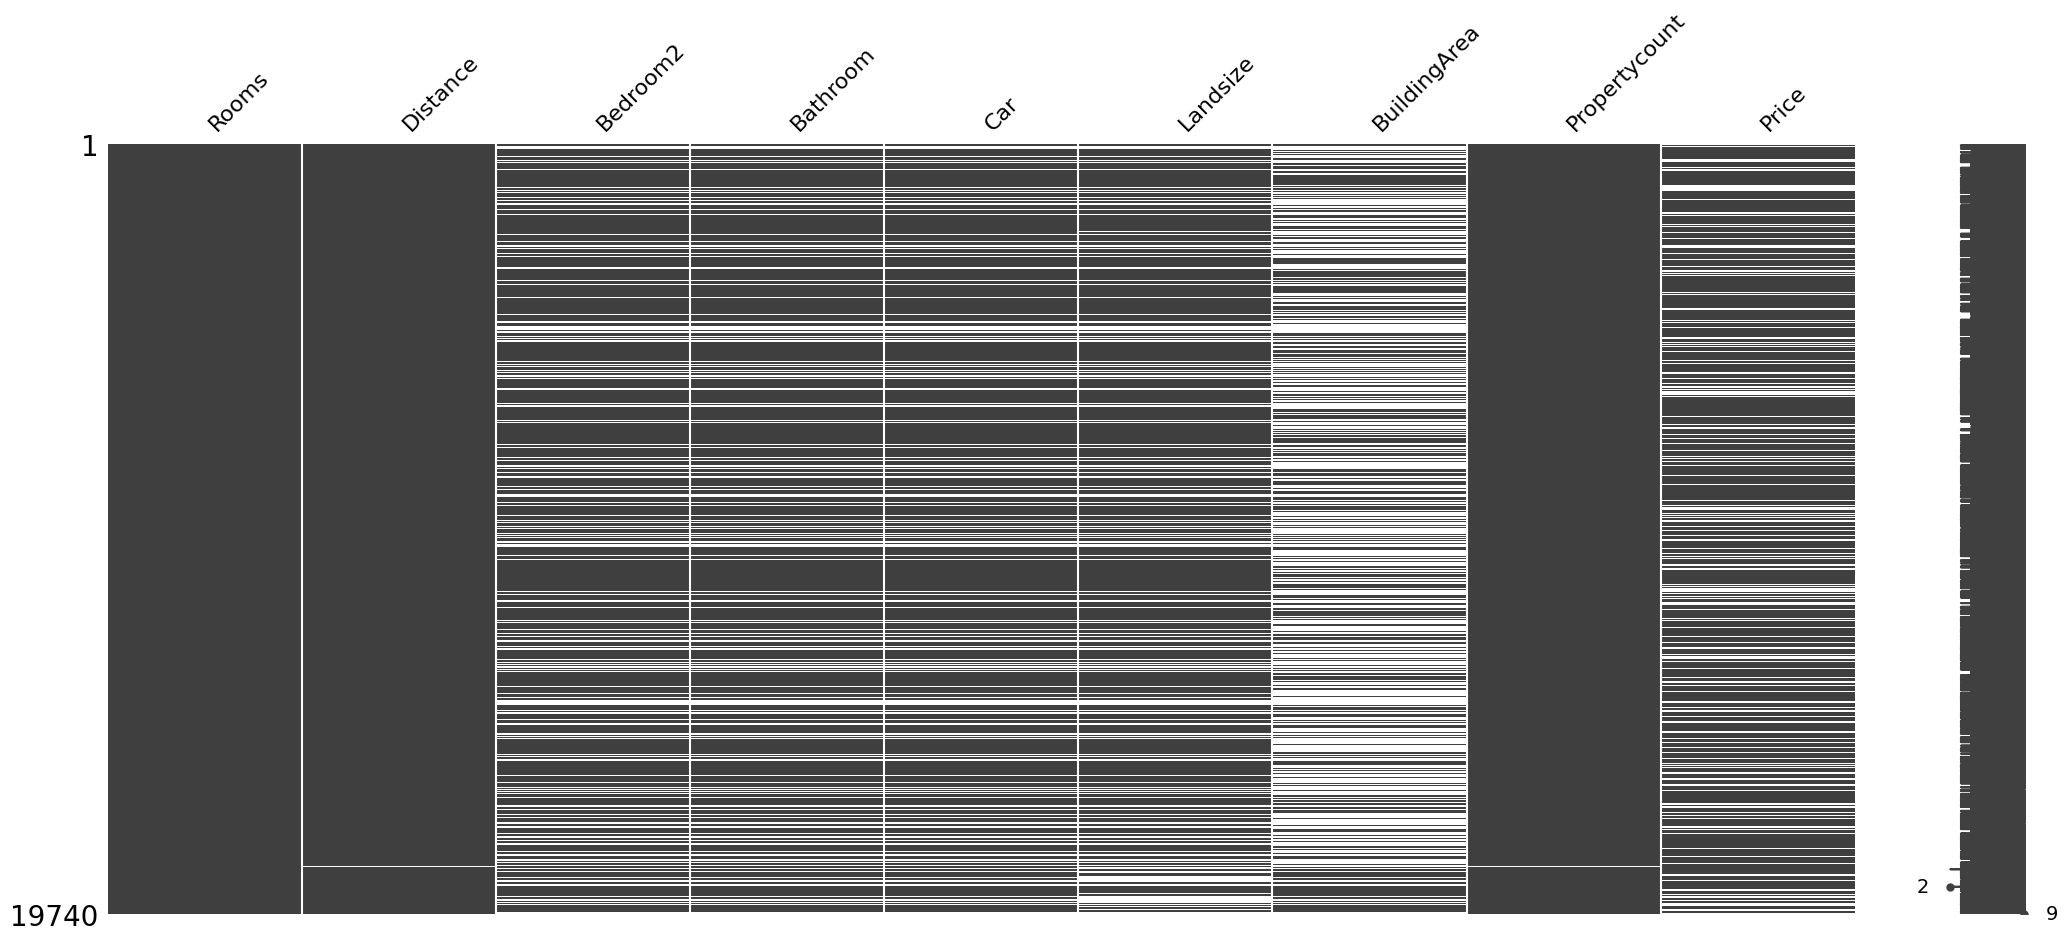

In [10]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df2)

<Axes: >

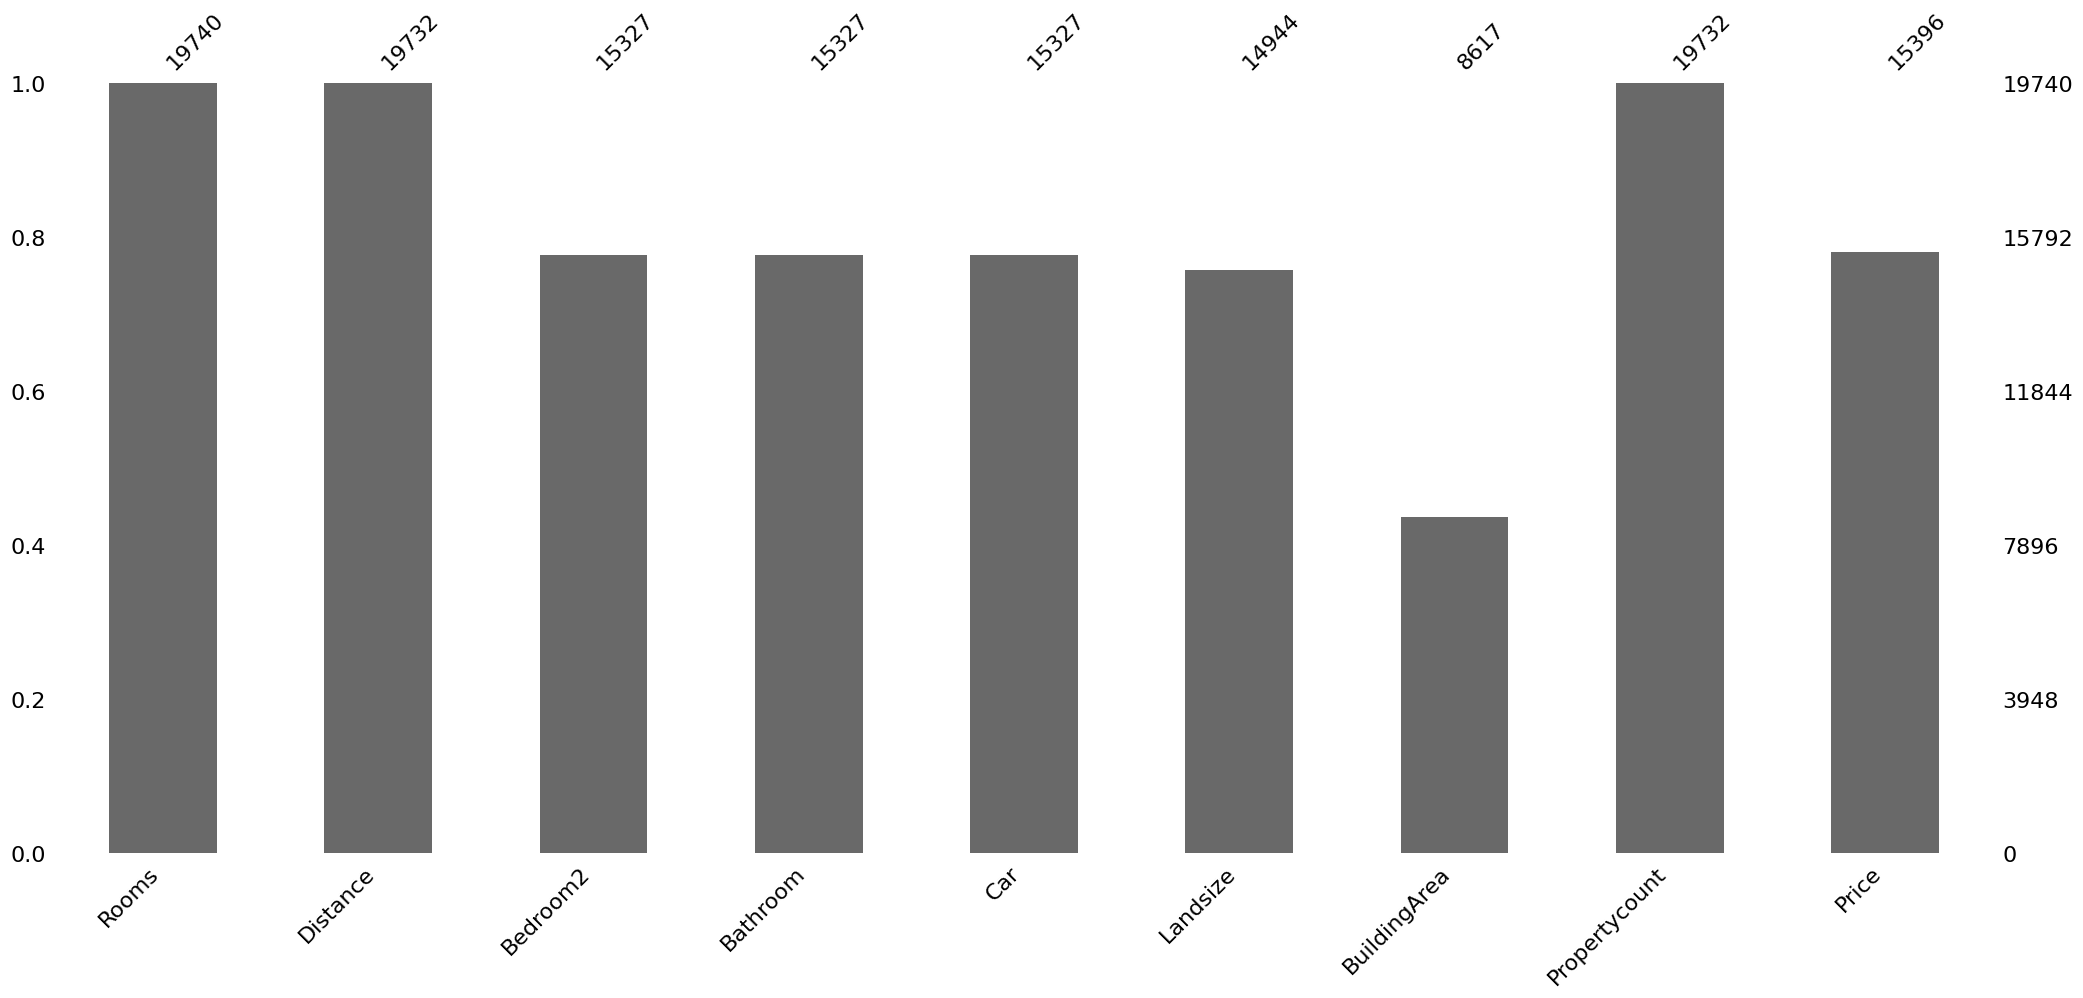

In [11]:
msno.bar(df2)

In [12]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df3 = pd.DataFrame(imputer.fit_transform(df2), columns=df2.columns)
df3

,Rooms,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Propertycount,Price
0,2.0,2.5,2.0,1.0,1.0,126.00000,196.806973,4019.0,1.054957e+06
1,2.0,2.5,2.0,1.0,1.0,202.00000,196.806973,4019.0,1.480000e+06
2,2.0,2.5,2.0,1.0,0.0,156.00000,79.000000,4019.0,1.035000e+06
3,3.0,2.5,3.0,2.0,1.0,0.00000,196.806973,4019.0,1.054957e+06
4,3.0,2.5,3.0,2.0,0.0,134.00000,150.000000,4019.0,1.465000e+06
...,...,...,...,...,...,...,...,...,...
19735,2.0,4.6,3.0,1.0,1.0,583.91709,585.000000,4380.0,5.600000e+05
19736,3.0,25.5,3.0,2.0,2.0,583.91709,333.000000,2940.0,5.253000e+05
19737,2.0,6.3,3.0,2.0,2.0,1999.00000,199.000000,6543.0,7.500000e+05
19738,6.0,6.3,3.0,2.0,1.0,2011.00000,238.000000,6543.0,2.450000e+06


<Axes: >

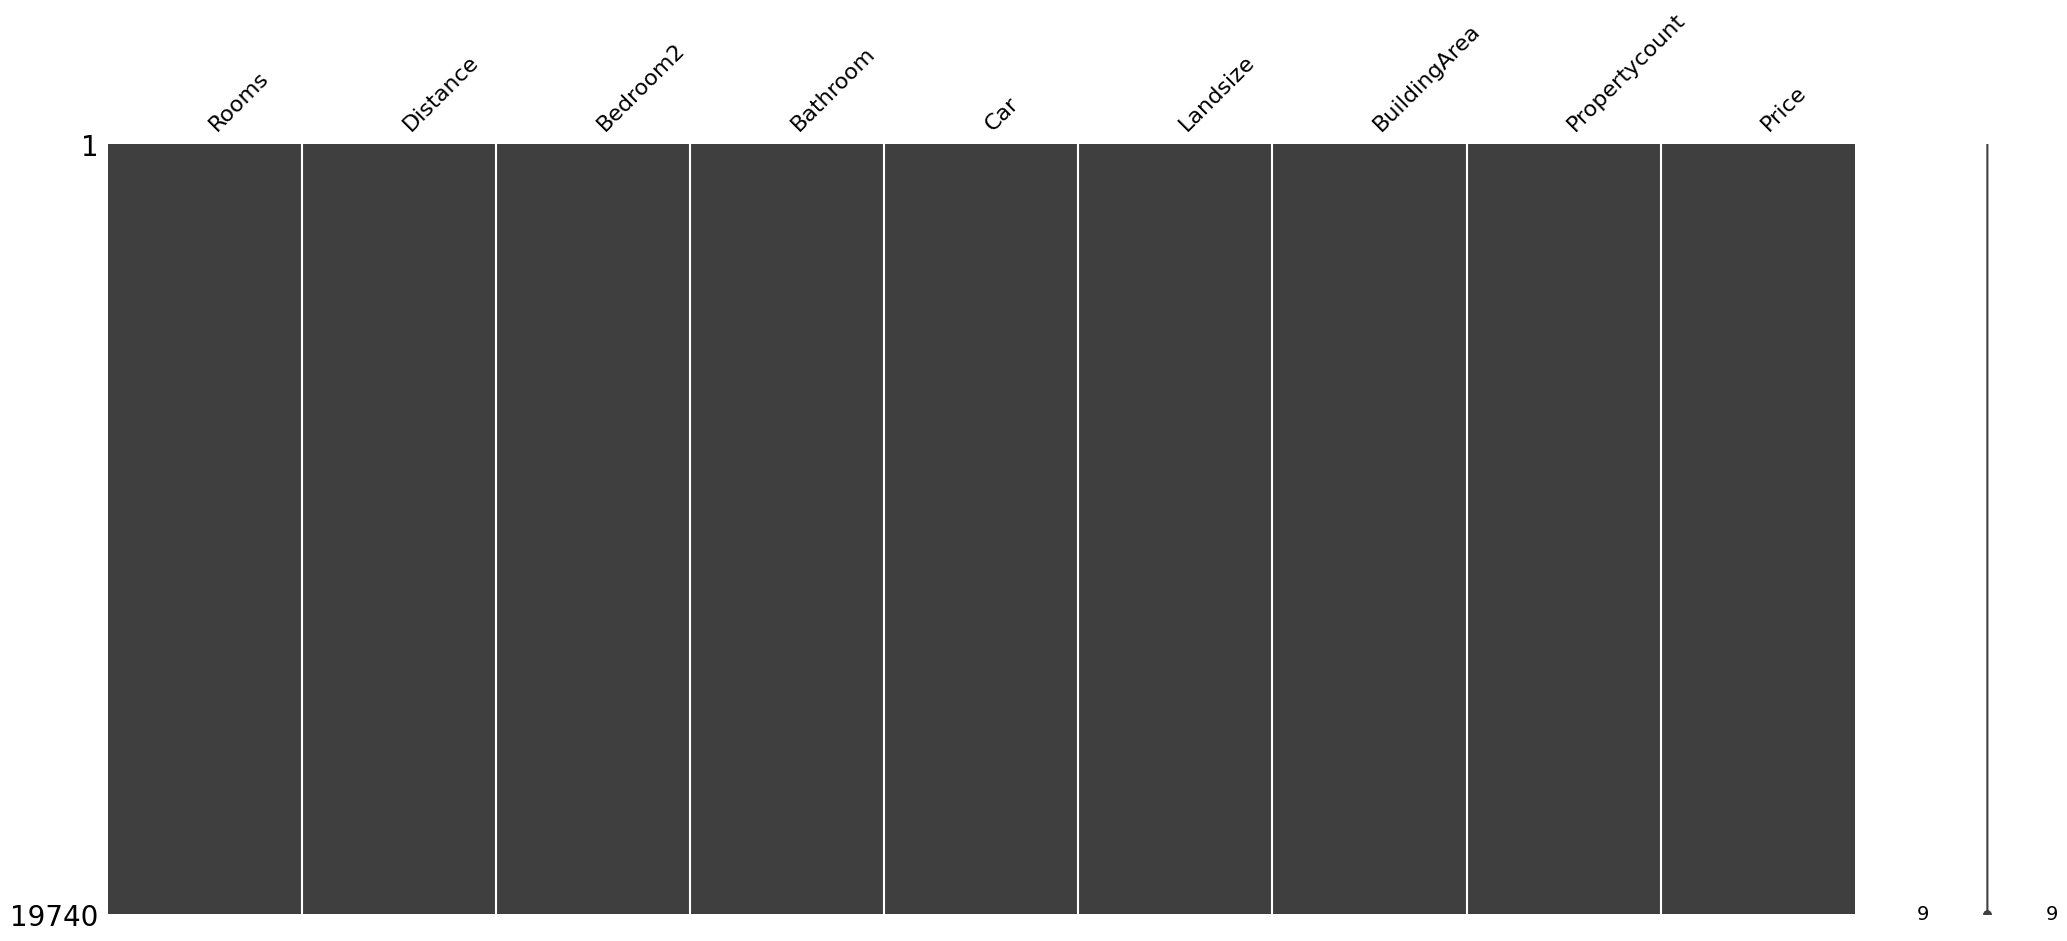

In [13]:
msno.matrix(df3)

In [14]:
cols = df3.columns[:-1]
X = df3[cols]
y = df3['Price']

In [15]:
import statsmodels.api as sm

model = sm.OLS(y,X)
result = model.fit()

print('회귀계수\n',result.params)
print('R=squared\n',result.rsquared)
print('P value\n',result.pvalues)

회귀계수
 Rooms            294371.005153
Distance         -23496.988924
Bedroom2           9619.034190
Bathroom         153450.013874
Car               45814.483818
Landsize              0.670134
BuildingArea         19.118400
Propertycount         7.495786
dtype: float64
R=squared
 0.8320357616277433
P value
 Rooms             0.000000e+00
Distance         3.070252e-284
Bedroom2          1.150098e-01
Bathroom         1.468789e-106
Car               2.508850e-24
Landsize          5.287350e-01
BuildingArea      4.347287e-02
Propertycount     8.631029e-27
dtype: float64


In [16]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.832
Model:                            OLS   Adj. R-squared (uncentered):              0.832
Method:                 Least Squares   F-statistic:                          1.222e+04
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        09:54:13   Log-Likelihood:                     -2.8670e+05
No. Observations:               19740   AIC:                                  5.734e+05
Df Residuals:                   19732   BIC:                                  5.735e+05
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Rooms          2.944e+05   5116.944     57.529      0.000    2.84e+05    3.04e+05
Distance       -2.35e+04    641.486    -36.629      0.000   -2.48e+04   -2.22e+04
Bedroom2       9619.0342   6102.909      1.576      0.115   -2343.181    2.16e+04
Bathroom       1.535e+05   6955.878     22.060      0.000     1.4e+05    1.67e+05
Car            4.581e+04   4495.752     10.191      0.000     3.7e+04    5.46e+04
Landsize          0.6701      1.064      0.630      0.529      -1.415       2.755
BuildingArea     19.1184      9.468      2.019      0.043       0.560      37.676
Propertycount     7.4958      0.699     10.731      0.000       6.127       8.865
==============================================================================
Omnibus:                    10727.056   Durbin-Watson:                   1.653
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           199988.120
Skew:                           2.207   Prob(JB):                         0.00
Kurtosis:                      17.955   Cond. No.                     2.02e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
#가장 유의하지 않은 Landsize 제외
X = df3[['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
       'BuildingArea', 'Propertycount']]
y = df3['Price']
model = sm.OLS(y,X)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.832
Model:                            OLS   Adj. R-squared (uncentered):              0.832
Method:                 Least Squares   F-statistic:                          1.396e+04
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        09:56:25   Log-Likelihood:                     -2.8670e+05
No. Observations:               19740   AIC:                                  5.734e+05
Df Residuals:                   19733   BIC:                                  5.735e+05
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Rooms          2.944e+05   5116.709     57.536      0.000    2.84e+05    3.04e+05
Distance      -2.348e+04    641.059    -36.631      0.000   -2.47e+04   -2.22e+04
Bedroom2       9587.3833   6102.609      1.571      0.116   -2374.244    2.15e+04
Bathroom       1.535e+05   6954.033     22.080      0.000     1.4e+05    1.67e+05
Car            4.584e+04   4495.500     10.197      0.000     3.7e+04    5.47e+04
BuildingArea     19.1908      9.467      2.027      0.043       0.634      37.747
Propertycount     7.5037      0.698     10.744      0.000       6.135       8.873
==============================================================================
Omnibus:                    10728.128   Durbin-Watson:                   1.653
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           200056.957
Skew:                           2.207   Prob(JB):                         0.00
Kurtosis:                      17.958   Cond. No.                     2.02e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
#Bedroom2 제외
X = df3[['Rooms', 'Distance', 'Bathroom', 'Car',
         'BuildingArea', 'Propertycount']]
y = df3['Price']
model = sm.OLS(y, X)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.832
Model:                            OLS   Adj. R-squared (uncentered):              0.832
Method:                 Least Squares   F-statistic:                          1.629e+04
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        09:57:17   Log-Likelihood:                     -2.8670e+05
No. Observations:               19740   AIC:                                  5.734e+05
Df Residuals:                   19734   BIC:                                  5.735e+05
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Rooms          2.997e+05   3835.888     78.135      0.000    2.92e+05    3.07e+05
Distance       -2.34e+04    639.067    -36.620      0.000   -2.47e+04   -2.21e+04
Bathroom       1.584e+05   6215.433     25.493      0.000    1.46e+05    1.71e+05
Car            4.728e+04   4400.746     10.744      0.000    3.87e+04    5.59e+04
BuildingArea     19.8090      9.459      2.094      0.036       1.268      38.350
Propertycount     7.6376      0.693     11.018      0.000       6.279       8.996
==============================================================================
Omnibus:                    10688.122   Durbin-Watson:                   1.654
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           198357.002
Skew:                           2.197   Prob(JB):                         0.00
Kurtosis:                      17.895   Cond. No.                     1.69e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.69e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
df3.corr()

,Rooms,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Propertycount,Price
Rooms,1.000000,0.269187,0.713647,0.465050,0.315823,0.027690,0.063147,-0.092805,0.441892
Distance,0.269187,1.000000,0.198491,0.082878,0.191013,0.041062,0.059510,-0.075737,-0.130879
Bedroom2,0.713647,0.198491,1.000000,0.595986,0.389490,0.023069,0.080291,-0.079796,0.335809
Bathroom,0.465050,0.082878,0.595986,1.000000,0.320351,0.032138,0.066778,-0.041444,0.325379
Car,0.315823,0.191013,0.389490,0.320351,1.000000,0.025044,0.066859,-0.024810,0.177339
Landsize,0.027690,0.041062,0.023069,0.032138,0.025044,1.000000,0.016474,0.011601,0.010406
BuildingArea,0.063147,0.059510,0.080291,0.066778,0.066859,0.016474,1.000000,-0.009088,0.028060
Propertycount,-0.092805,-0.075737,-0.079796,-0.041444,-0.024810,0.011601,-0.009088,1.000000,-0.043741
Price,0.441892,-0.130879,0.335809,0.325379,0.177339,0.010406,0.028060,-0.043741,1.000000


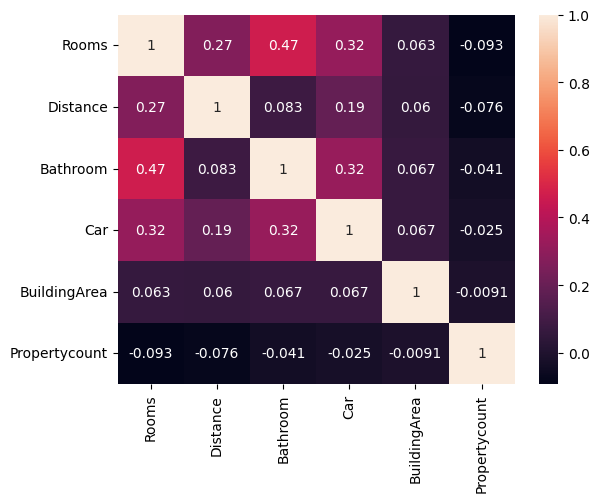

In [24]:
import seaborn as sns
sns.heatmap(X.corr(), annot=True)
plt.show()

In [25]:
#Propertycount 제외
X = df3[['Rooms', 'Distance', 'Bathroom', 'Car', 'BuildingArea']]
y = df3['Price']
model = sm.OLS(y, X)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.831
Model:                            OLS   Adj. R-squared (uncentered):              0.831
Method:                 Least Squares   F-statistic:                          1.940e+04
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        10:08:14   Log-Likelihood:                     -2.8676e+05
No. Observations:               19740   AIC:                                  5.735e+05
Df Residuals:                   19735   BIC:                                  5.736e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Rooms         3.073e+05   3784.647     81.204      0.000       3e+05    3.15e+05
Distance     -2.278e+04    638.483    -35.675      0.000    -2.4e+04   -2.15e+04
Bathroom      1.689e+05   6161.577     27.409      0.000    1.57e+05    1.81e+05
Car           5.156e+04   4396.977     11.725      0.000    4.29e+04    6.02e+04
BuildingArea    22.8397      9.484      2.408      0.016       4.250      41.429
==============================================================================
Omnibus:                    10391.398   Durbin-Watson:                   1.663
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           189269.774
Skew:                           2.119   Prob(JB):                         0.00
Kurtosis:                      17.565   Cond. No.                         813.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""